# Heart Disease Risk Project - Keshab Role

This notebook performs:
- Model training (Random Forest, XGBoost, CatBoost)
- SHAP feature importance generation
- SHAP consistency check between models
- Model saving

## Outputs Generated

Models:
- rf_model.pkl
- xgb_model.pkl
- catboost_model.pkl

Tables:
- catboost_shap_importance.csv
- xgboost_shap_importance.csv
- shap_consistency_table.csv
- model_training_summary.csv

Plots:
- catboost_shap_beeswarm.png
- catboost_shap_bar.png
- xgboost_shap_beeswarm.png
- xgboost_shap_bar.png

In [3]:
# Install required libraries (run once if needed)
!pip install pandas numpy scikit-learn xgboost catboost shap matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.3 MB/s eta 0:00:00


In [4]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

## Load Cleaned Training Dataset

In [9]:
# Load cleaned dataset generated by preprocessing step
df = pd.read_csv("/content/cleaned_train.csv")

# Separate features and target
X = df.drop(columns=['id', 'target', 'dataset_Hungary', 'dataset_Switzerland', 'dataset_VA Long Beach'])
y = df["target"]

print("Dataset shape:", df.shape)

print(X.columns.tolist())

Dataset shape: (736, 23)
['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'sex_Male', 'cp_atypical angina', 'cp_non-anginal', 'cp_typical angina', 'fbs_True', 'restecg_normal', 'restecg_st-t abnormality', 'exang_True', 'slope_flat', 'slope_upsloping', 'thal_normal', 'thal_reversable defect']


## Model Training
In this section we train three machine learning models on the cleaned dataset:

- Random Forest
- XGBoost
- CatBoost

These models will later be used for SHAP explainability analysis.

### Train Random Forest Model

In [10]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X, y)

print("Random Forest training completed")

Random Forest training completed


In [11]:
# Save model
joblib.dump(rf_model, "rf_model.pkl")

print("Random Forest model saved")

Random Forest model saved


### Train XGBoost Model

In [12]:
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    eval_metric="logloss",
    random_state=42
)

xgb_model.fit(X, y)

print("XGBoost training completed")

# Save model
joblib.dump(xgb_model, "xgb_model.pkl")

print("XGBoost model saved")

XGBoost training completed
XGBoost model saved


### Train CatBoost Model

In [13]:
cat_model = CatBoostClassifier(
    iterations=200,
    learning_rate=0.05,
    depth=4,
    verbose=False,
    random_state=42
)

cat_model.fit(X, y)

print("CatBoost training completed")

# Save model
joblib.dump(cat_model, "catboost_model.pkl")

print("CatBoost model saved")

CatBoost training completed
CatBoost model saved


## SHAP Explainability Analysis

In this section we compute SHAP values to understand feature importance
for tree-based models.

We analyze:
- CatBoost model
- XGBoost model

SHAP values help interpret how each feature contributes to model predictions.

### SHAP Analysis — CatBoost Model

In [14]:
import numpy as np
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Create SHAP explainer for CatBoost
explainer_cat = shap.TreeExplainer(cat_model)

# Compute SHAP values
shap_values_cat = explainer_cat.shap_values(X)
print("SHAP values for CatBoost computed")

# Save to Google Drive
np.save('/content/drive/MyDrive/shap_values_cat.npy', shap_values_cat)
print("SHAP values saved to Google Drive!")

Mounted at /content/drive
SHAP values for CatBoost computed
SHAP values saved to Google Drive!


### SHAP Beeswarm Plot — CatBoost

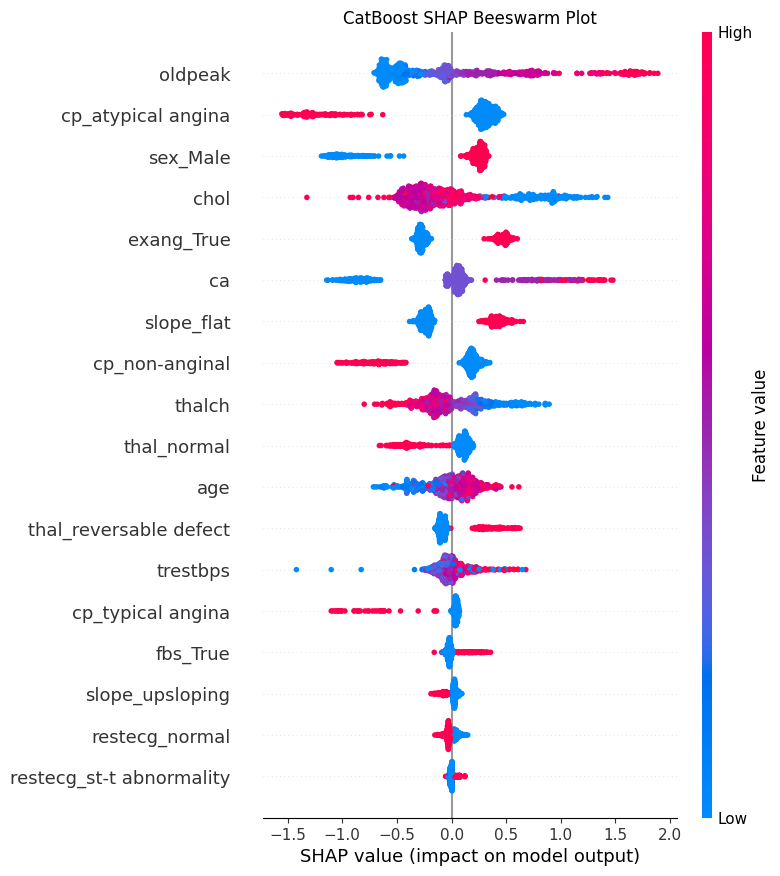

In [15]:
# SHAP Beeswarm Plot (CatBoost)

import matplotlib.pyplot as plt

shap.summary_plot(shap_values_cat, X, show=False)

plt.title("CatBoost SHAP Beeswarm Plot")
plt.savefig("catboost_shap_beeswarm.png", bbox_inches="tight", dpi=300)
plt.show()

### SHAP Feature Importance — CatBoost

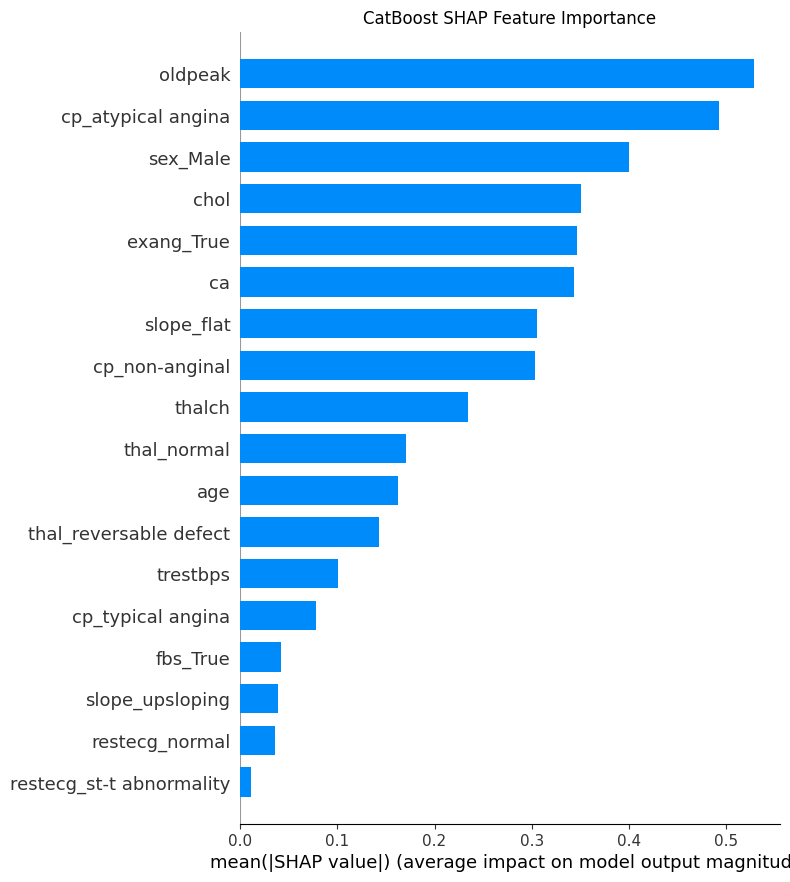

In [16]:
# SHAP Bar Plot (CatBoost)

shap.summary_plot(shap_values_cat, X, plot_type="bar", show=False)

plt.title("CatBoost SHAP Feature Importance")
plt.savefig("catboost_shap_bar.png", bbox_inches="tight", dpi=300)
plt.show()

### Generate SHAP Importance Table (CatBoost)

In [17]:
# Compute mean absolute SHAP values
cat_importance = np.abs(shap_values_cat).mean(axis=0)

cat_shap_df = pd.DataFrame({
    "feature": X.columns,
    "shap_importance": cat_importance
})

# Sort by importance
cat_shap_df = cat_shap_df.sort_values(by="shap_importance", ascending=False)

# Add ranking
cat_shap_df["rank"] = range(1, len(cat_shap_df) + 1)

cat_shap_df.head()

,feature,shap_importance,rank
4,oldpeak,0.528868,1
7,cp_atypical angina,0.492734,2
6,sex_Male,0.400086,3
2,chol,0.350766,4
13,exang_True,0.346677,5


In [18]:
cat_shap_df.to_csv("catboost_shap_importance.csv", index=False)

print("CatBoost SHAP importance table saved")

CatBoost SHAP importance table saved


### SHAP Analysis — XGBoost Model

In [19]:
# Create SHAP explainer for XGBoost
explainer_xgb = shap.TreeExplainer(xgb_model)

# Compute SHAP values
shap_values_xgb = explainer_xgb.shap_values(X)

print("SHAP values for XGBoost computed")

SHAP values for XGBoost computed


### SHAP Beeswarm Plot — XGBoost

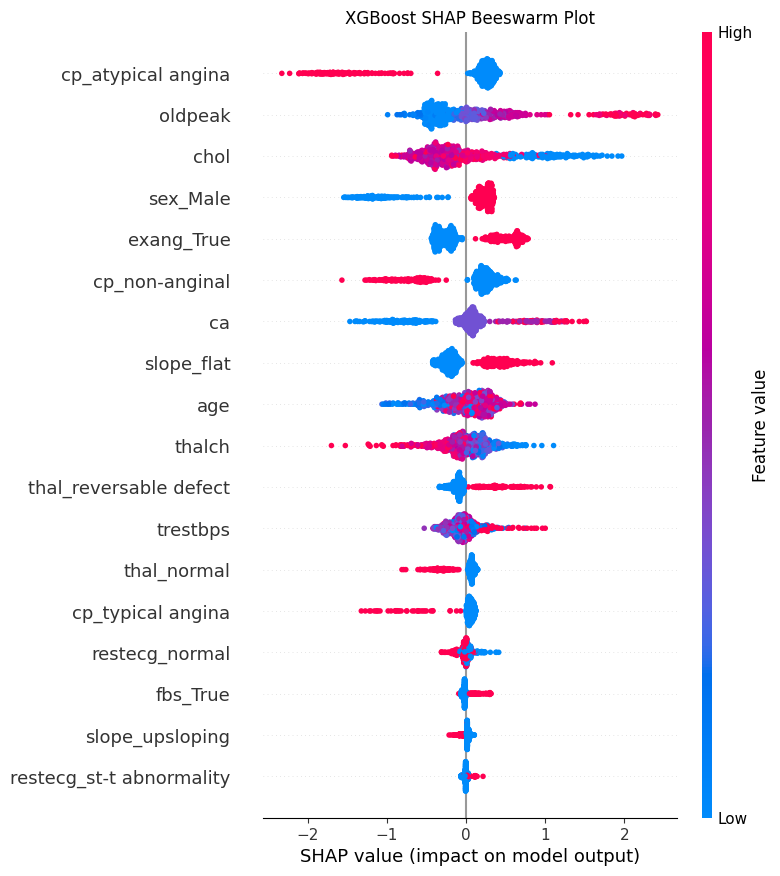

In [20]:
# SHAP Beeswarm Plot (XGBoost)

shap.summary_plot(shap_values_xgb, X, show=False)

plt.title("XGBoost SHAP Beeswarm Plot")
plt.savefig("xgboost_shap_beeswarm.png", bbox_inches="tight", dpi=300)
plt.show()

### SHAP Feature Importance — XGBoost

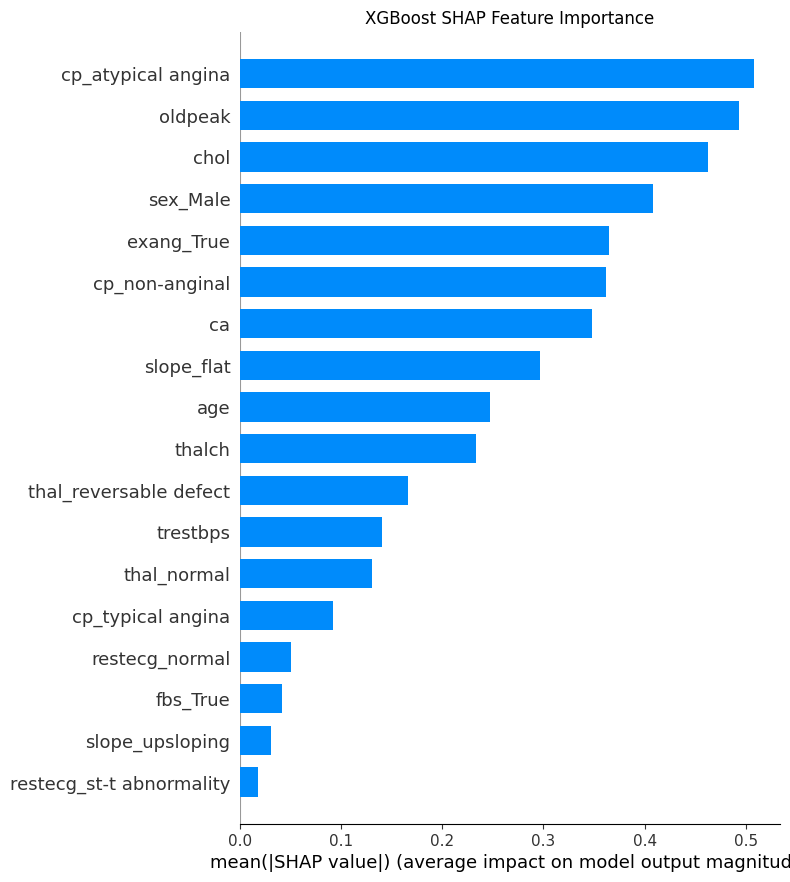

In [21]:
# SHAP Bar Plot (XGBoost)

shap.summary_plot(shap_values_xgb, X, plot_type="bar", show=False)

plt.title("XGBoost SHAP Feature Importance")
plt.savefig("xgboost_shap_bar.png", bbox_inches="tight", dpi=300)
plt.show()

### Generate SHAP Importance Table (XGBoost)

In [22]:
# Compute mean absolute SHAP values
xgb_importance = np.abs(shap_values_xgb).mean(axis=0)

xgb_shap_df = pd.DataFrame({
    "feature": X.columns,
    "shap_importance": xgb_importance
})

# Sort by importance
xgb_shap_df = xgb_shap_df.sort_values(by="shap_importance", ascending=False)

# Add ranking
xgb_shap_df["rank"] = range(1, len(xgb_shap_df) + 1)

xgb_shap_df.head()

,feature,shap_importance,rank
7,cp_atypical angina,0.508479,1
4,oldpeak,0.493615,2
2,chol,0.463025,3
6,sex_Male,0.408670,4
13,exang_True,0.365241,5


In [23]:
xgb_shap_df.to_csv("xgboost_shap_importance.csv", index=False)

print("XGBoost SHAP importance table saved")

XGBoost SHAP importance table saved


### SHAP Consistency Check (CatBoost vs XGBoost)

This section compares the top 10 features ranked by SHAP importance
from CatBoost and XGBoost models.

Consistency between models increases confidence in feature importance.

In [24]:
# Top 10 features from CatBoost
top_cat = cat_shap_df.head(10)[["feature", "rank"]]
top_cat = top_cat.rename(columns={"rank": "catboost_rank"})

# Top 10 features from XGBoost
top_xgb = xgb_shap_df.head(10)[["feature", "rank"]]
top_xgb = top_xgb.rename(columns={"rank": "xgboost_rank"})

top_cat

,feature,catboost_rank
4,oldpeak,1
7,cp_atypical angina,2
6,sex_Male,3
2,chol,4
13,exang_True,5
5,ca,6
14,slope_flat,7
8,cp_non-anginal,8
3,thalch,9
16,thal_normal,10


In [25]:
# Merge tables on feature name
shap_comparison = pd.merge(
    top_cat,
    top_xgb,
    on="feature",
    how="outer"
)

shap_comparison = shap_comparison.sort_values(by="catboost_rank")

shap_comparison

,feature,catboost_rank,xgboost_rank
6,oldpeak,1.0,2.0
3,cp_atypical angina,2.0,1.0
7,sex_Male,3.0,4.0
2,chol,4.0,3.0
5,exang_True,5.0,5.0
1,ca,6.0,7.0
8,slope_flat,7.0,8.0
4,cp_non-anginal,8.0,6.0
10,thalch,9.0,10.0
9,thal_normal,10.0,NaN


In [26]:
shap_comparison.to_csv("shap_consistency_table.csv", index=False)

print("SHAP consistency table saved")

SHAP consistency table saved


### SHAP Consistency Check
Compare top-10 features from CatBoost and XGBoost.

In [27]:
cat_features = set(top_cat["feature"])
xgb_features = set(top_xgb["feature"])

common_features = cat_features.intersection(xgb_features)

print("Number of common features:", len(common_features))
print("Common features:", common_features)

if len(common_features) >= 6:
    print("SHAP rankings are consistent.")
else:
    print("SHAP rankings inconsistent. Retraining required.")

Number of common features: 9
Common features: {'thalch', 'cp_non-anginal', 'oldpeak', 'sex_Male', 'cp_atypical angina', 'chol', 'exang_True', 'ca', 'slope_flat'}
SHAP rankings are consistent.


### Model Training Summary
This table records model training time and key hyperparameters.

In [28]:
import time

model_summary = pd.DataFrame({
    "model": ["Random Forest", "XGBoost", "CatBoost"],
    "n_estimators": [200, 200, 200],
    "max_depth": ["-", 4, 4],
    "learning_rate": ["-", 0.05, 0.05]
})

model_summary

,model,n_estimators,max_depth,learning_rate
0,Random Forest,200,-,-
1,XGBoost,200,4,0.05
2,CatBoost,200,4,0.05


In [29]:
model_summary.to_csv("model_training_summary.csv", index=False)
print("Model training summary saved")

Model training summary saved
